# TD-based Control in Acrobot

## Init lib & help functions

In [36]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import seaborn as sns

from IPython.display import display, clear_output
import time

In [56]:
def discretize(obs, bins):
    return tuple(
        np.digitize(obs[i], bins[i])
        for i in range(len(obs))
    )

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(3)
    return np.argmax(Q[state])

def get_ema(returns, alpha):
    ema = np.zeros_like(returns)
    if len(returns) > 0:
        ema[0] = returns[0]
        for t in range(1, len(returns)):
            ema[t] = alpha * returns[t] + (1 - alpha) * ema[t-1]
    return ema

def get_ema_2d(trajectories, alpha):
    smoothed = np.zeros_like(trajectories)
    for i in range(trajectories.shape[0]):
        val = trajectories[i, 0]
        for j in range(trajectories.shape[1]):
            val = alpha * trajectories[i, j] + (1 - alpha) * val
            smoothed[i, j] = val
    return smoothed

In [3]:
def make_bins(num_bins):
    bins = []

    # cos and sin ∈ [-1,1]
    for _ in range(4):
        bins.append(np.linspace(-1, 1, num_bins - 1))

    # velocities (use env limits)
    bins.append(np.linspace(-4*np.pi, 4*np.pi, num_bins - 1))
    bins.append(np.linspace(-9*np.pi, 9*np.pi, num_bins - 1))
    return bins

In [4]:
def plot_returns(returns, alpha=0.1):
    plt.figure()
    returns = np.array(returns)

    # Plot raw returns with transparency
    plt.plot(returns, alpha=0.3, label='Raw Returns')

    # Compute EMA
    ema = np.zeros_like(returns)
    if len(returns) > 0:
        ema[0] = returns[0]
        for t in range(1, len(returns)):
            ema[t] = alpha * returns[t] + (1 - alpha) * ema[t-1]
        
        plt.plot(ema, label=f'EMA (alpha={alpha})', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Return vs Episode")
    plt.legend()
    plt.grid(True)
    plt.show()
    

def get_return(Q, max_steps=500, num_bins=10, episodes=1000):
    bins = make_bins(num_bins)
    env = gym.make("Acrobot-v1")

    returns = []

    for _ in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)

        reward_sum = 0

        for _ in range(max_steps):

            # Greedy action (no exploration)
            action = np.argmax(Q[state])

            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)
            reward_sum += reward  # Each step gives a reward of -1, so we can just count steps

            if terminated or truncated:
                break
    
        returns.append(reward_sum)

    env.close()
    return np.mean(returns), np.var(returns)

In [5]:
def visualize_policy(Q, episodes=3, max_steps=500, online=False, num_bins=10):
        
    envs = [gym.make("Acrobot-v1", render_mode="rgb_array") 
            for _ in range(episodes)]
    bins = make_bins(num_bins)
    states = []
    dones = [False] * episodes
    
    # reset all envs
    for env in envs:
        obs, _ = env.reset()
        states.append(discretize(obs, bins))

    for _ in range(max_steps):

        frames = []

        for i in range(episodes):
            if not dones[i]:
                if online:
                    # epsilon-greedy action selection for online visualization
                    action = epsilon_greedy(Q, states[i], epsilon=0.1)  # No exploration
                else:
                    action = np.argmax(Q[states[i]])
                obs, _, terminated, truncated, _ = envs[i].step(action)
                states[i] = discretize(obs, bins)
                dones[i] = terminated or truncated

            frames.append(envs[i].render())

        clear_output(wait=True)

        fig, axes = plt.subplots(1, episodes, figsize=(5*episodes, 4))
        if episodes == 1:
            axes = [axes]

        for ax, frame in zip(axes, frames):
            ax.imshow(frame)
            ax.axis("off")

        plt.show()
        time.sleep(0.02)

        if all(dones):
            break

    for env in envs:
        env.close()

## Code for simulations with algo & constants abstracted out

In [62]:
gamma = 0.99
episodes=5000
max_steps=500
epsilon_decay=0.998  # Reaches 0.1 at around 1150 episodes  


def rl_agent(algo='SARSA', num_bins=10, eta=0, alpha=0.1, epsilon_start=0.1, epsilon_min=0.1, decay=False):
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)
    epsilon = epsilon_start

    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)
    returns = []


    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # Modified Reward (eta=0 -> reward = -1)
            c1, s1, c2, s2 = obs_next[:4]
            h = -c1 - (c1*c2 - s1*s2)

            reward = (eta*h)/2 + np.sign(-1 + eta*h) * ((2 - eta*h)/2)

            if algo == 'QLearning':
                Q[state][action] += alpha * (reward + gamma * np.max(Q[state_next]) - Q[state][action])
            elif algo == 'SARSA':
                Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        if decay:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep+1) % 1000 == 0:
            print("Episode: ", ep+1)

    env.close()
    return Q, returns

In [73]:
def rl_agent_offline(Q, episodes):
    max_steps = 500
    num_bins = 10
    
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)
    returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)
        action = np.argmax(Q[state])
        total_reward = 0

        for _ in range(max_steps):
            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state = discretize(obs_next, bins)
            action = np.argmax(Q[state])

            total_reward += reward
            if done: break
        
        returns.append(total_reward)
    
    env.close()
    return returns

## OG Implementation

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


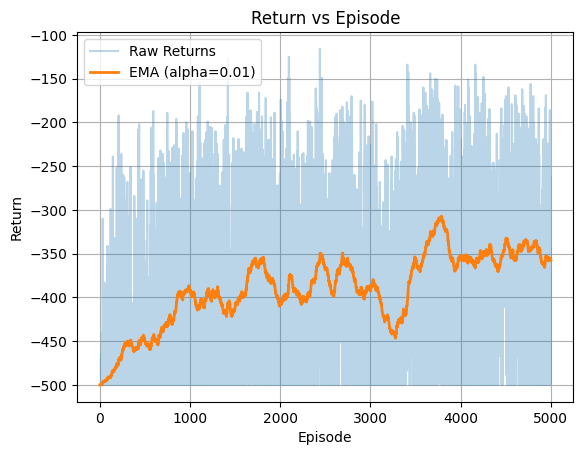

In [17]:
Q_SARSA, Returns_SARSA = rl_agent(algo='SARSA')
plot_returns(Returns_SARSA, alpha=0.01)

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


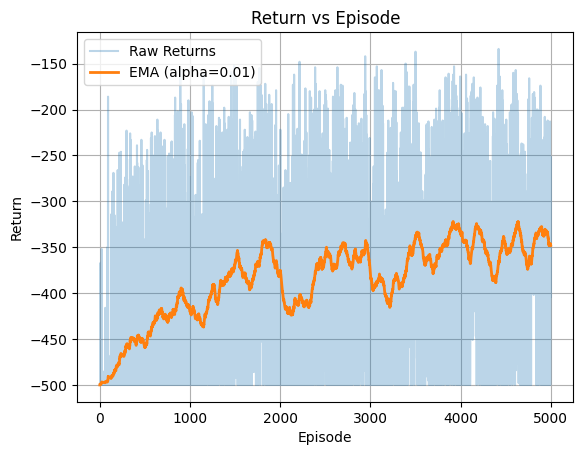

In [18]:
Q_QLearning, Returns_QLearning = rl_agent(algo='QLearning')
plot_returns(Returns_QLearning, alpha=0.01)

## Hyperparameter tuning

#### SARSA

In [85]:
sarsa_data = joblib.load('./outputs/sweep_results_SARSA.pkl')

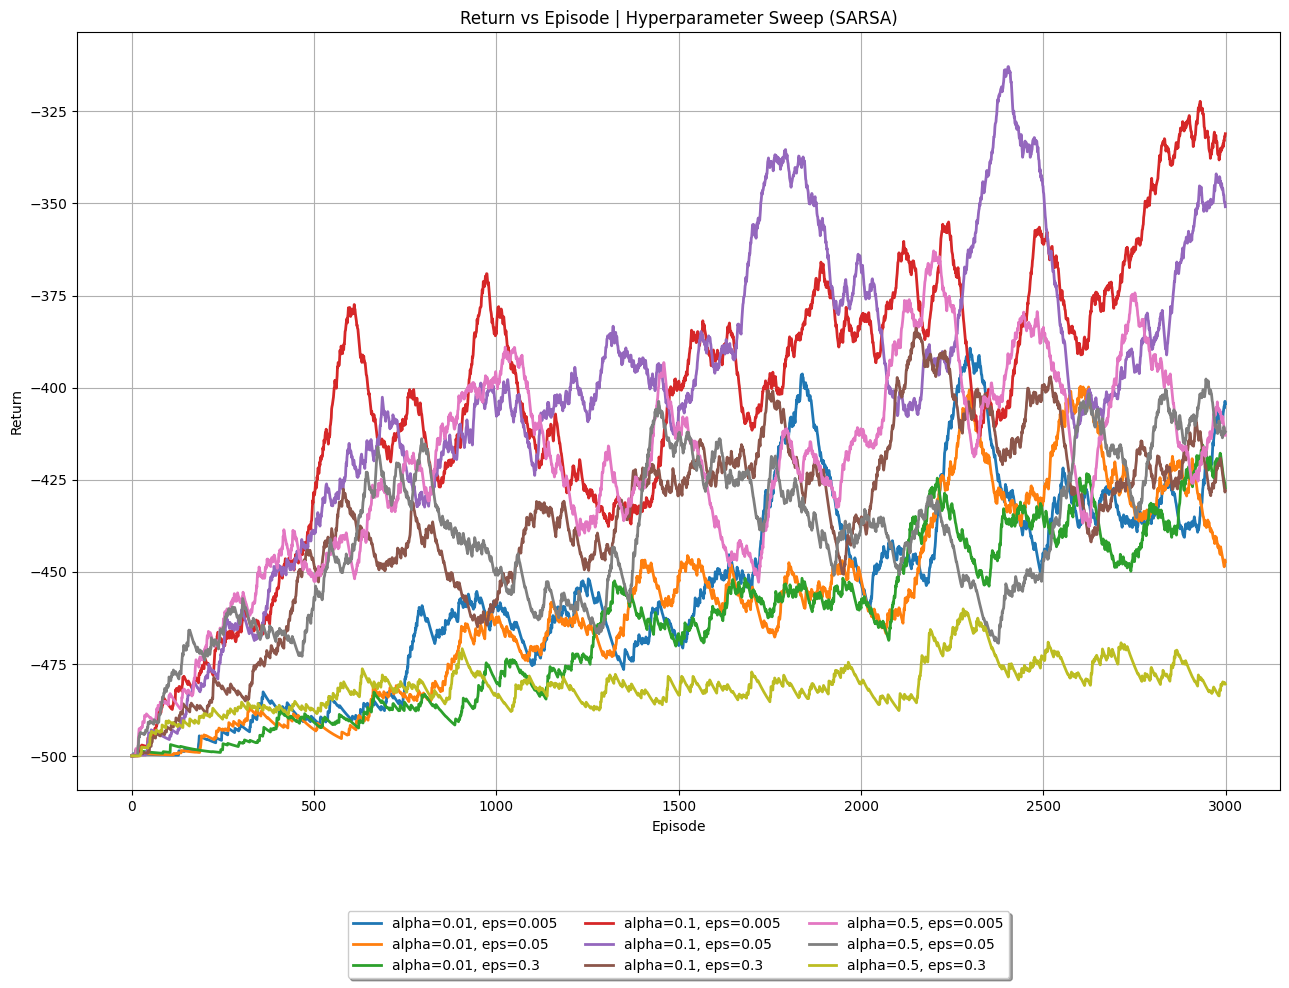

In [86]:
plt.figure(figsize=(13, 10))

for entry in sarsa_data:
    if entry['alpha'] in (0.05, 0.2) or entry['epsilon'] in (0.01, 0.1, 0.2):
        continue
    ema_returns = get_ema(entry['returns'], alpha=0.01)
    plt.plot(ema_returns, label=f"alpha={entry['alpha']}, eps={entry['epsilon']}", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return vs Episode | Hyperparameter Sweep (SARSA)")
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # (horizontal, vertical)
    ncol=3,                      # Organizes labels into columns
    fancybox=True, 
    shadow=True
)
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.grid(True)
plt.show()

Text(120.72222222222221, 0.5, 'Alpha ($\\alpha$)')

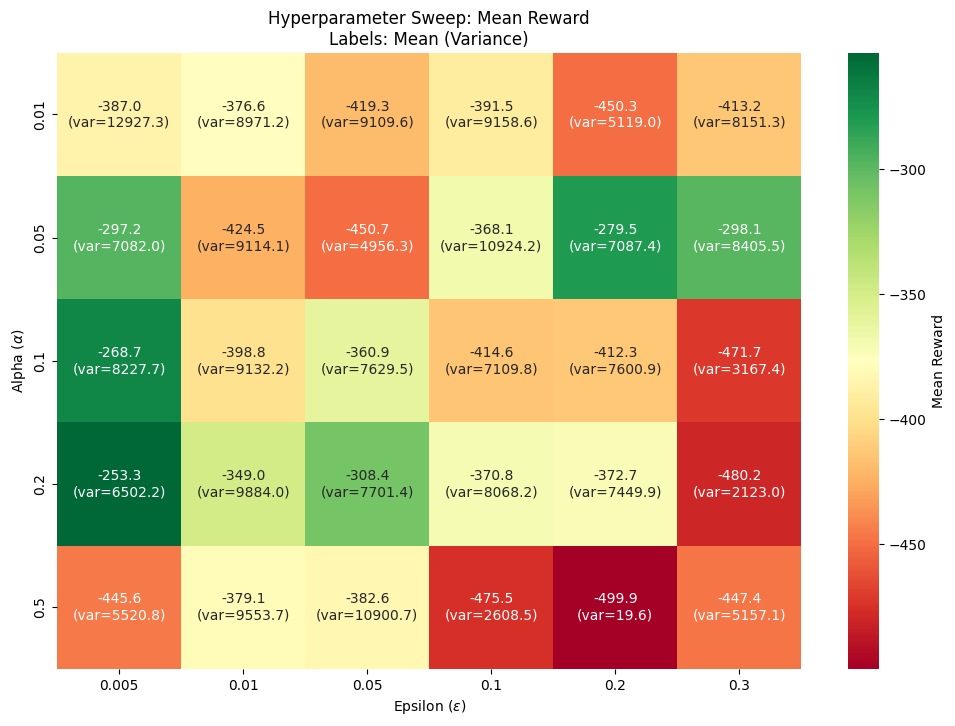

In [53]:
df = pd.DataFrame(sarsa_data)
pivot_mean = df.pivot(index='alpha', columns='epsilon', values='offline_mean')
pivot_var = df.pivot(index='alpha', columns='epsilon', values='offline_var')

annot_matrix = []
for i in range(len(pivot_mean.index)):
    row_annot = []
    for j in range(len(pivot_mean.columns)):
        m = pivot_mean.iloc[i, j]
        v = pivot_var.iloc[i, j]
        row_annot.append(f"{m:.1f}\n(var={v:.1f})")
    annot_matrix.append(row_annot)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_mean, annot=annot_matrix, fmt="", cmap="RdYlGn", cbar_kws={'label': 'Mean Reward'})

plt.title("Hyperparameter Sweep: Mean Reward\nLabels: Mean (Variance)")
plt.xlabel("Epsilon ($\epsilon$)")
plt.ylabel("Alpha ($\\alpha$)")

In [54]:
print("Top 3 Hyperparameter Combinations (SARSA):")
top_combinations = df.sort_values(by='offline_mean', ascending=False).head(3)
for idx, row in top_combinations.iterrows():
    print(f"Alpha: {row['alpha']}, Epsilon: {row['epsilon']}, Mean Reward: {row['offline_mean']:.2f}, Variance: {row['offline_var']:.2f}")

Top 3 Hyperparameter Combinations (SARSA):
Alpha: 0.2, Epsilon: 0.005, Mean Reward: -253.30, Variance: 6502.18
Alpha: 0.1, Epsilon: 0.005, Mean Reward: -268.74, Variance: 8227.71
Alpha: 0.05, Epsilon: 0.2, Mean Reward: -279.53, Variance: 7087.36


#### QLearning

In [83]:
qlearn_data = joblib.load('./outputs/sweep_results_QLearning.pkl')

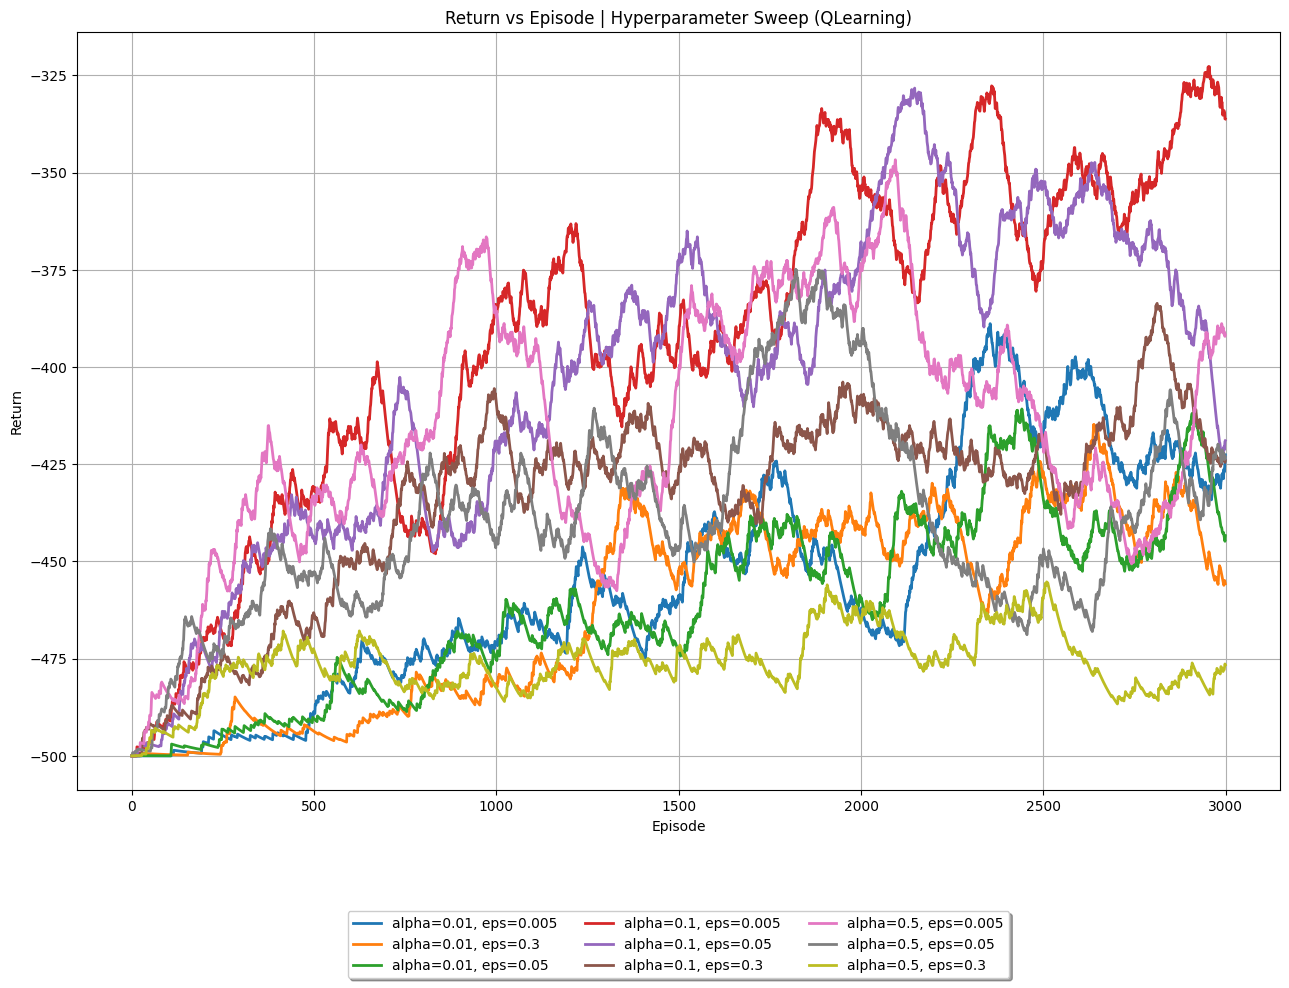

In [84]:
plt.figure(figsize=(13, 10))

for entry in qlearn_data:
    if entry['alpha'] in (0.05, 0.2) or entry['epsilon'] in (0.01, 0.1, 0.2):
        continue
    ema_returns = get_ema(entry['returns'], alpha=0.01)
    plt.plot(ema_returns, label=f"alpha={entry['alpha']}, eps={entry['epsilon']}", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return vs Episode | Hyperparameter Sweep (QLearning)")
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # (horizontal, vertical)
    ncol=3,                      # Organizes labels into columns
    fancybox=True, 
    shadow=True
)
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.grid(True)
plt.show()

Text(120.72222222222221, 0.5, 'Alpha ($\\alpha$)')

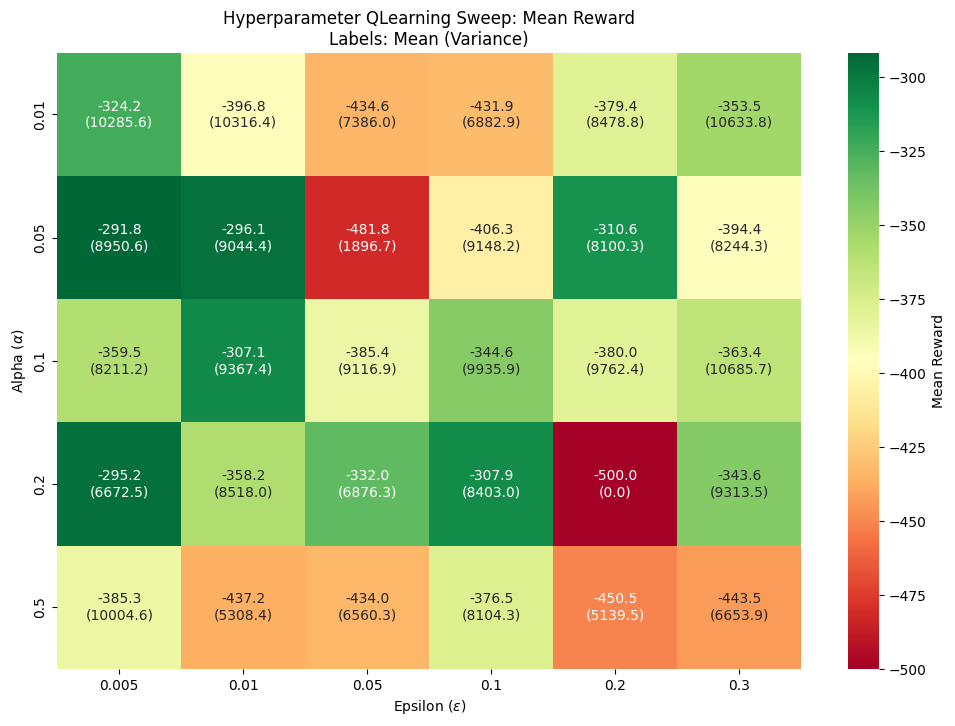

In [51]:
qdf = pd.DataFrame(qlearn_data)
pivot_mean = qdf.pivot(index='alpha', columns='epsilon', values='offline_mean')
pivot_var = qdf.pivot(index='alpha', columns='epsilon', values='offline_var')

annot_matrix = []
for i in range(len(pivot_mean.index)):
    row_annot = []
    for j in range(len(pivot_mean.columns)):
        m = pivot_mean.iloc[i, j]
        v = pivot_var.iloc[i, j]
        row_annot.append(f"{m:.1f}\n({v:.1f})")
    annot_matrix.append(row_annot)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_mean, annot=annot_matrix, fmt="", cmap="RdYlGn", cbar_kws={'label': 'Mean Reward'})

plt.title("Hyperparameter QLearning Sweep: Mean Reward\nLabels: Mean (Variance)")
plt.xlabel("Epsilon ($\epsilon$)")
plt.ylabel("Alpha ($\\alpha$)")

In [52]:
print("Top 3 Hyperparameter Combinations (Q Learning):")
top_combinations = qdf.sort_values(by='offline_mean', ascending=False).head(3)
for idx, row in top_combinations.iterrows():
    print(f"Alpha: {row['alpha']}, Epsilon: {row['epsilon']}, Mean Reward: {row['offline_mean']:.2f}, Variance: {row['offline_var']:.2f}")

Top 3 Hyperparameter Combinations (Q Learning):
Alpha: 0.05, Epsilon: 0.005, Mean Reward: -291.82, Variance: 8950.55
Alpha: 0.2, Epsilon: 0.005, Mean Reward: -295.19, Variance: 6672.54
Alpha: 0.05, Epsilon: 0.01, Mean Reward: -296.07, Variance: 9044.44


### Comparison

In [63]:
sarsa_data_10seed = np.array(joblib.load('./outputs/random_seeds_SARSA.pkl'))
sarsa_smoothed = get_ema_2d(sarsa_data_10seed, alpha=0.01)

sarsa_mean = sarsa_smoothed.mean(axis=0)
sarsa_std = sarsa_smoothed.std(axis=0)
episodes_x_array = np.arange(len(sarsa_mean))

qlearn_data_10seed = np.array(joblib.load('./outputs/random_seeds_QLearning.pkl'))
qlearn_smoothed = get_ema_2d(qlearn_data_10seed, alpha=0.01)

qlearn_mean = qlearn_smoothed.mean(axis=0)
qlearn_std = qlearn_smoothed.std(axis=0)

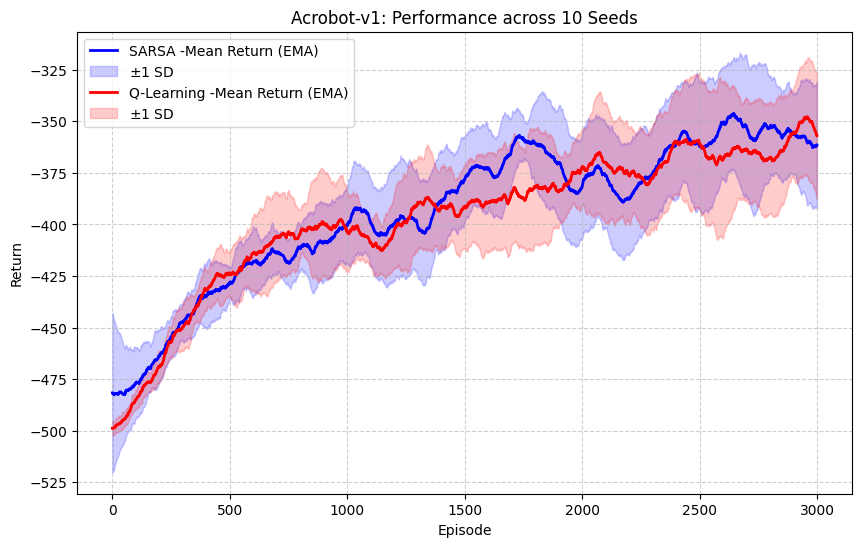

In [64]:
plt.figure(figsize=(10, 6))

plt.plot(episodes_x_array, sarsa_mean, label='SARSA -Mean Return (EMA)', color='blue', linewidth=2)
plt.fill_between(
    episodes_x_array, 
    sarsa_mean - sarsa_std, 
    sarsa_mean + sarsa_std, 
    color='blue', 
    alpha=0.2, 
    label='$\pm 1$ SD'
)

plt.plot(episodes_x_array, qlearn_mean, label='Q-Learning -Mean Return (EMA)', color='red', linewidth=2)
plt.fill_between(
    episodes_x_array, 
    qlearn_mean - qlearn_std, 
    qlearn_mean + qlearn_std, 
    color='red', 
    alpha=0.2, 
    label='$\pm 1$ SD'
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Acrobot-v1: Performance across 10 Seeds")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Epsilon Decay variant

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


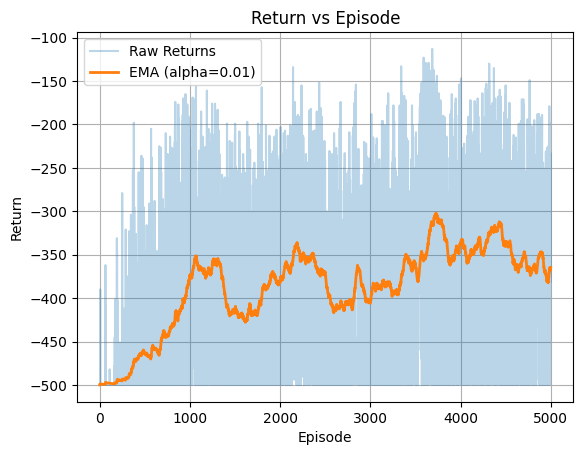

In [40]:
Q_SARSA, Returns_SARSA = rl_agent(algo='SARSA', epsilon_start=1.0, decay=True)
plot_returns(Returns_SARSA , alpha=0.01)

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


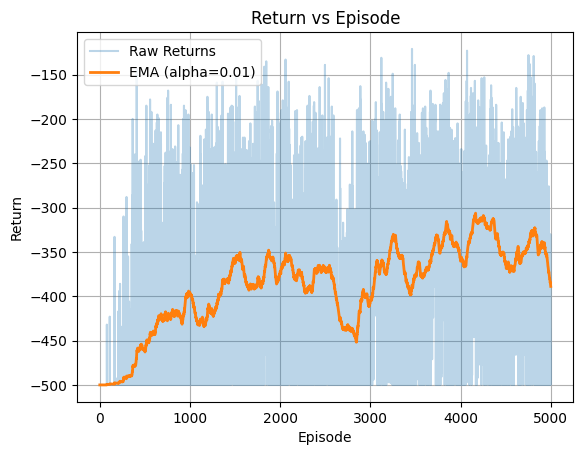

In [55]:
Q_QLearning, Returns_QLearning = rl_agent(algo='QLearning', epsilon_start=1.0, decay=True)
plot_returns(Returns_QLearning , alpha=0.01)

## Bin size exploration

Evaluating SARSA with bin size: 5
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000
Evaluating SARSA with bin size: 15
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000
Evaluating SARSA with bin size: 20
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


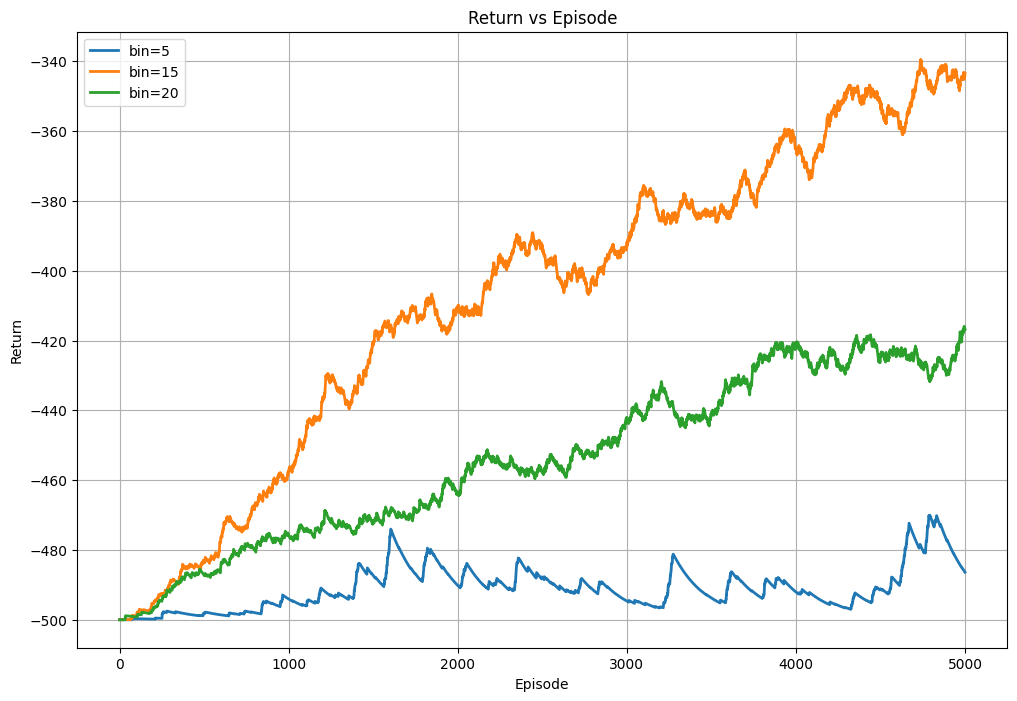

In [93]:
plt.figure(figsize=(12, 8))

for bin_size in (5, 15, 20):
    print(f"Evaluating SARSA with bin size: {bin_size}")
    _, returns = rl_agent(algo='SARSA', num_bins=bin_size, epsilon_start=1.0, decay=True)
    ema_returns = get_ema(returns, 0.005)
    plt.plot(ema_returns, label=f'bin={bin_size}', linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return vs Episode")
plt.legend()
plt.grid(True)
plt.show()

## Modified Reward

In [76]:
Etas = [0.5, 1, 5, 100]
Q_eta_dict = {}
Returns_eta_dict = {}

for i, eta in enumerate(Etas):
    print(f"Evaluating Q-Learning with eta: {eta}")
    Q_eta, Returns_eta = rl_agent(algo='QLearning', epsilon_start=1.0, decay=True, eta=eta)
    Q_eta_dict[eta] = Q_eta
    Returns_eta_dict[eta] = Returns_eta

Evaluating Q-Learning with eta: 0.5
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000
Evaluating Q-Learning with eta: 1
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000
Evaluating Q-Learning with eta: 5
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000
Evaluating Q-Learning with eta: 100
Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


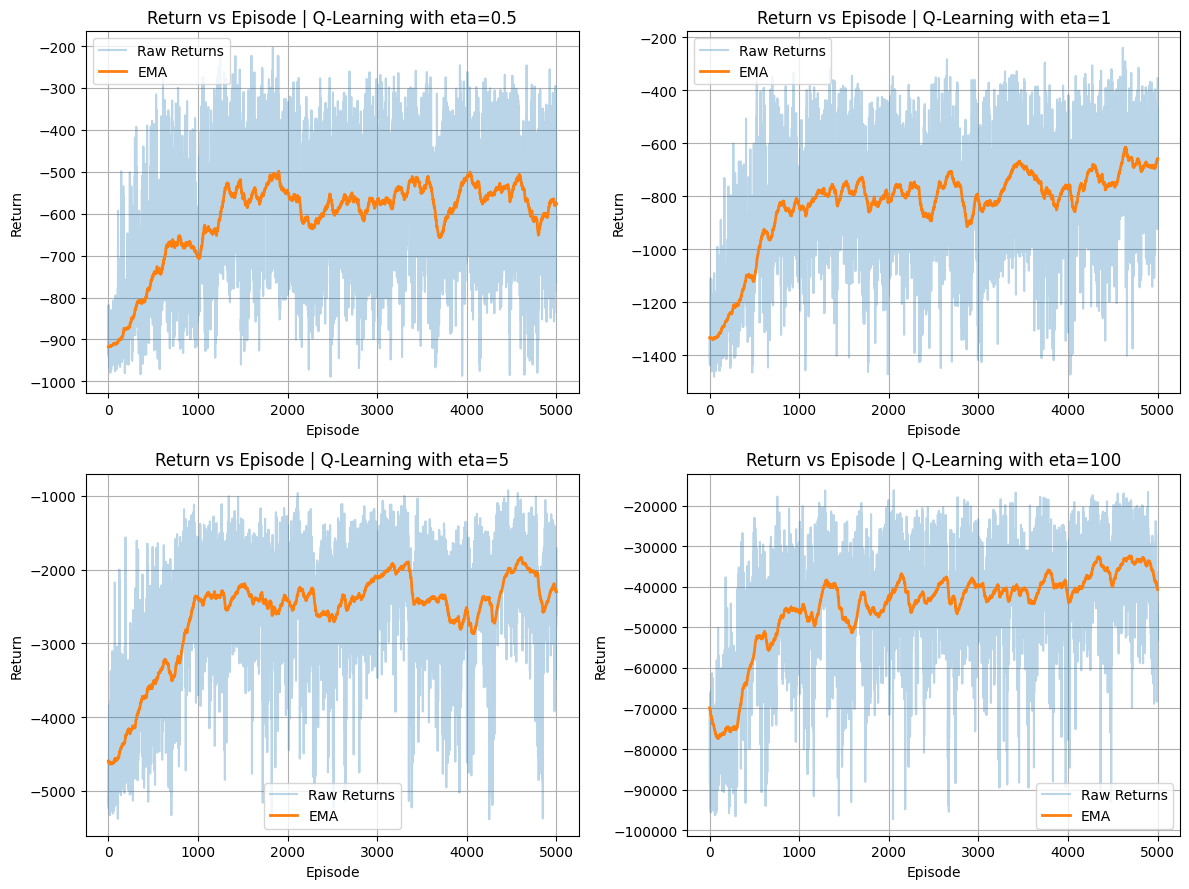

In [81]:
plt.figure(figsize=(12, 9))
for i, eta in enumerate(Etas):
    plt.subplot(2, 2, i+1)
    plt.plot(Returns_eta_dict[eta], alpha=0.3, label='Raw Returns')
    ema = get_ema(Returns_eta_dict[eta], alpha=0.01)
    plt.plot(ema, label=f'EMA', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(f"Return vs Episode | Q-Learning with eta={eta}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

#### Comparison of offline performance

Visualizing policy for eta=0.5
Visualizing policy for eta=1
Visualizing policy for eta=5
Visualizing policy for eta=100


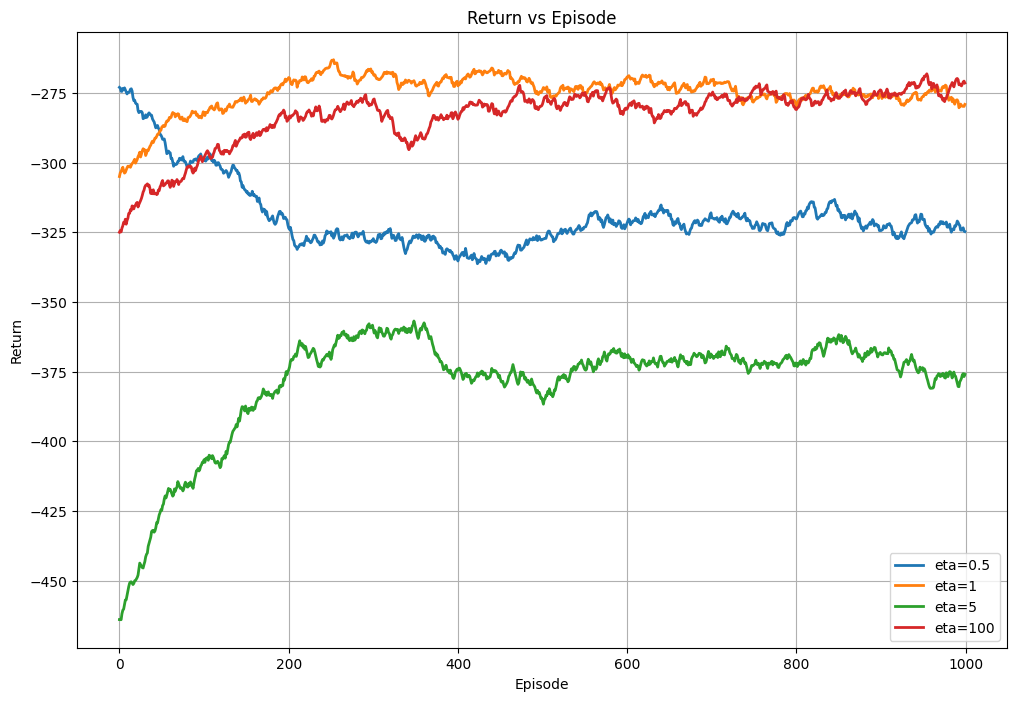

In [ ]:
plt.figure(figsize=(12, 8))

for eta in Etas:
    print(f"Visualizing policy for eta={eta}")
    returns = rl_agent_offline(Q_eta_dict[eta], episodes=1000)
    ema_returns = get_ema(returns, alpha=0.01)
    plt.plot(ema_returns, label=f'eta={eta}', linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return vs Episode")
plt.legend()
plt.grid(True)
plt.show()

## Lil' fun

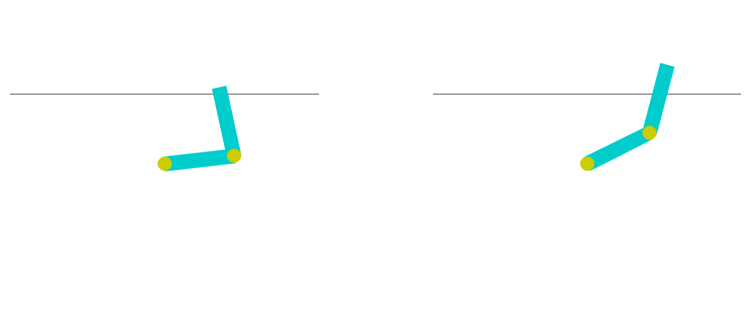

In [13]:
visualize_policy(Q_SARSA, episodes=2)

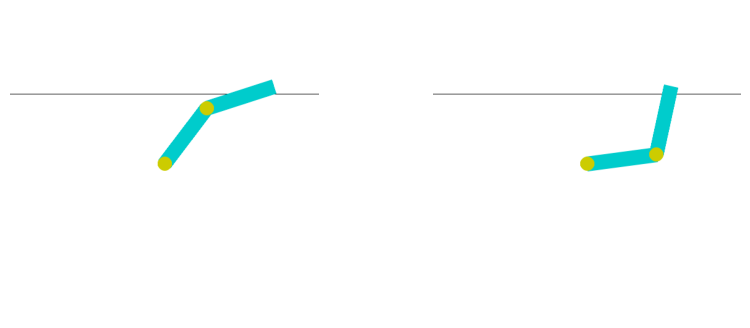

In [14]:
visualize_policy(Q_QLearning, episodes=2)

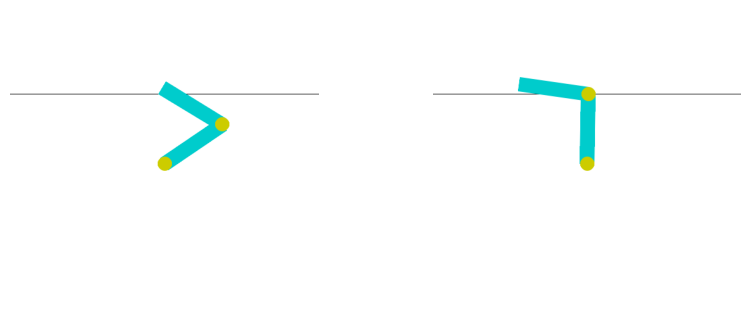

In [15]:
visualize_policy(Q_eta_Reward, episodes=2)